<a href="https://colab.research.google.com/github/bamSirikorn/BSC_DPDM2025/blob/main/Ch5_Classification2_10_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##data

###dataset

In [1]:
import pandas as pd
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/dpdm24_DATA'

In [16]:
from sklearn.datasets import load_digits
digits = load_digits()
X,y  = digits.data,digits.target
print(X.shape)
print(y.shape)
print(len(digits.target_names))
print(f"First 5 target labels:{y[:5]}")
mnist = load_digits()

(1797, 64)
(1797,)
10
First 5 target labels:[0 1 2 3 4]


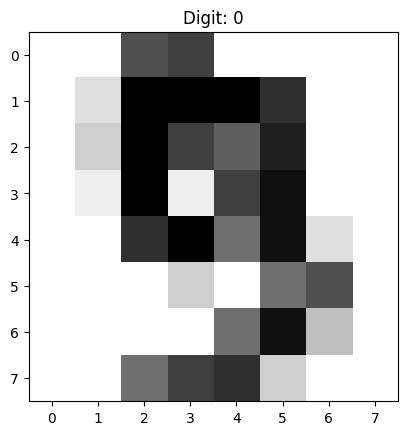

In [24]:
import matplotlib.pyplot as plt
first_image = X[9]
image_reshaped = first_image.reshape((8, 8))
plt.imshow(image_reshaped, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title(f'Digit: {y[0]}') # Use y[0] to get the digit label for the title
plt.show(True)

มี rules ,yhp
มีโค้งไหม

In [22]:
import numpy as np
df = pd.DataFrame(digits.data)
df['target'] = digits.target
print("Dataframe created successfully with shape",df.shape)

Dataframe created successfully with shape (1797, 65)


In [23]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [25]:
X.shape

(1797, 64)

In [30]:
X_train = X[:1700]
y_train = y[:1700]
X_test = X[1700:]
y_test = y[1700:]

##import

In [28]:
from sklearn.tree import DecisionTreeClassifier

##defind

In [51]:
tree0 = DecisionTreeClassifier(random_state=6)

##Train

In [63]:
tree0.fit(X_train,y_train)

DecisionTreeClassifier(random_state=6)

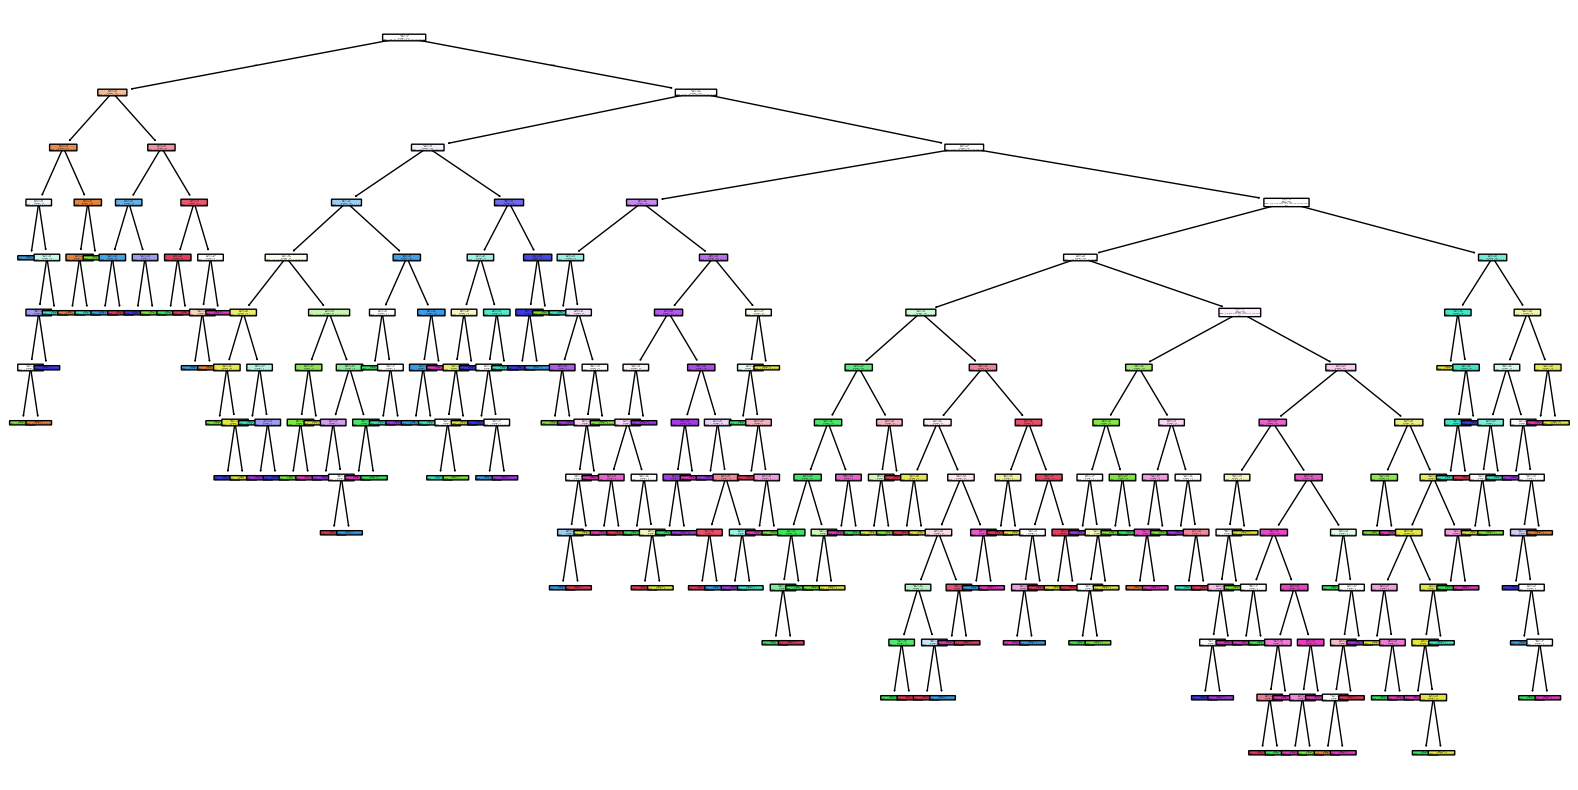

In [42]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(tree0,filled=True,rounded=True)
plt.show()




#Model Construction
- Import
- defind (hyper-parameter)
- train(fitting)
- evaluate (test/trian)

##Evalution

In [53]:
X_test

array([[ 0.,  0.,  4., ...,  1.,  0.,  0.],
       [ 0.,  0.,  4., ..., 15.,  5.,  0.],
       [ 0.,  0.,  7., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [64]:
y_predict = tree0.predict(X_test)

In [55]:
y_predict

array([9, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2,
       0, 1, 2, 6, 8, 8, 7, 4, 3, 4, 6, 6, 6, 4, 9, 1, 8, 0, 9, 6, 2, 8,
       2, 0, 0, 4, 7, 6, 3, 2, 1, 7, 4, 6, 3, 1, 2, 9, 1, 7, 6, 8, 4, 8,
       1, 4, 0, 5, 5, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 4,
       4, 8, 1, 4, 9, 0, 8, 9, 8])

In [56]:
y_test

array([5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2,
       0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8,
       2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4, 6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3,
       1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 8, 8, 4, 9, 0, 8, 9, 8])

accuracy

In [65]:
from sklearn.metrics import accuracy_score

In [66]:
accuracy_score(y_test,y_predict)

0.7938144329896907

##Pre_pruning

In [67]:
from sklearn.tree import DecisionTreeClassifier
tree1 = DecisionTreeClassifier(random_state=6,max_depth=3)
tree1.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=6)

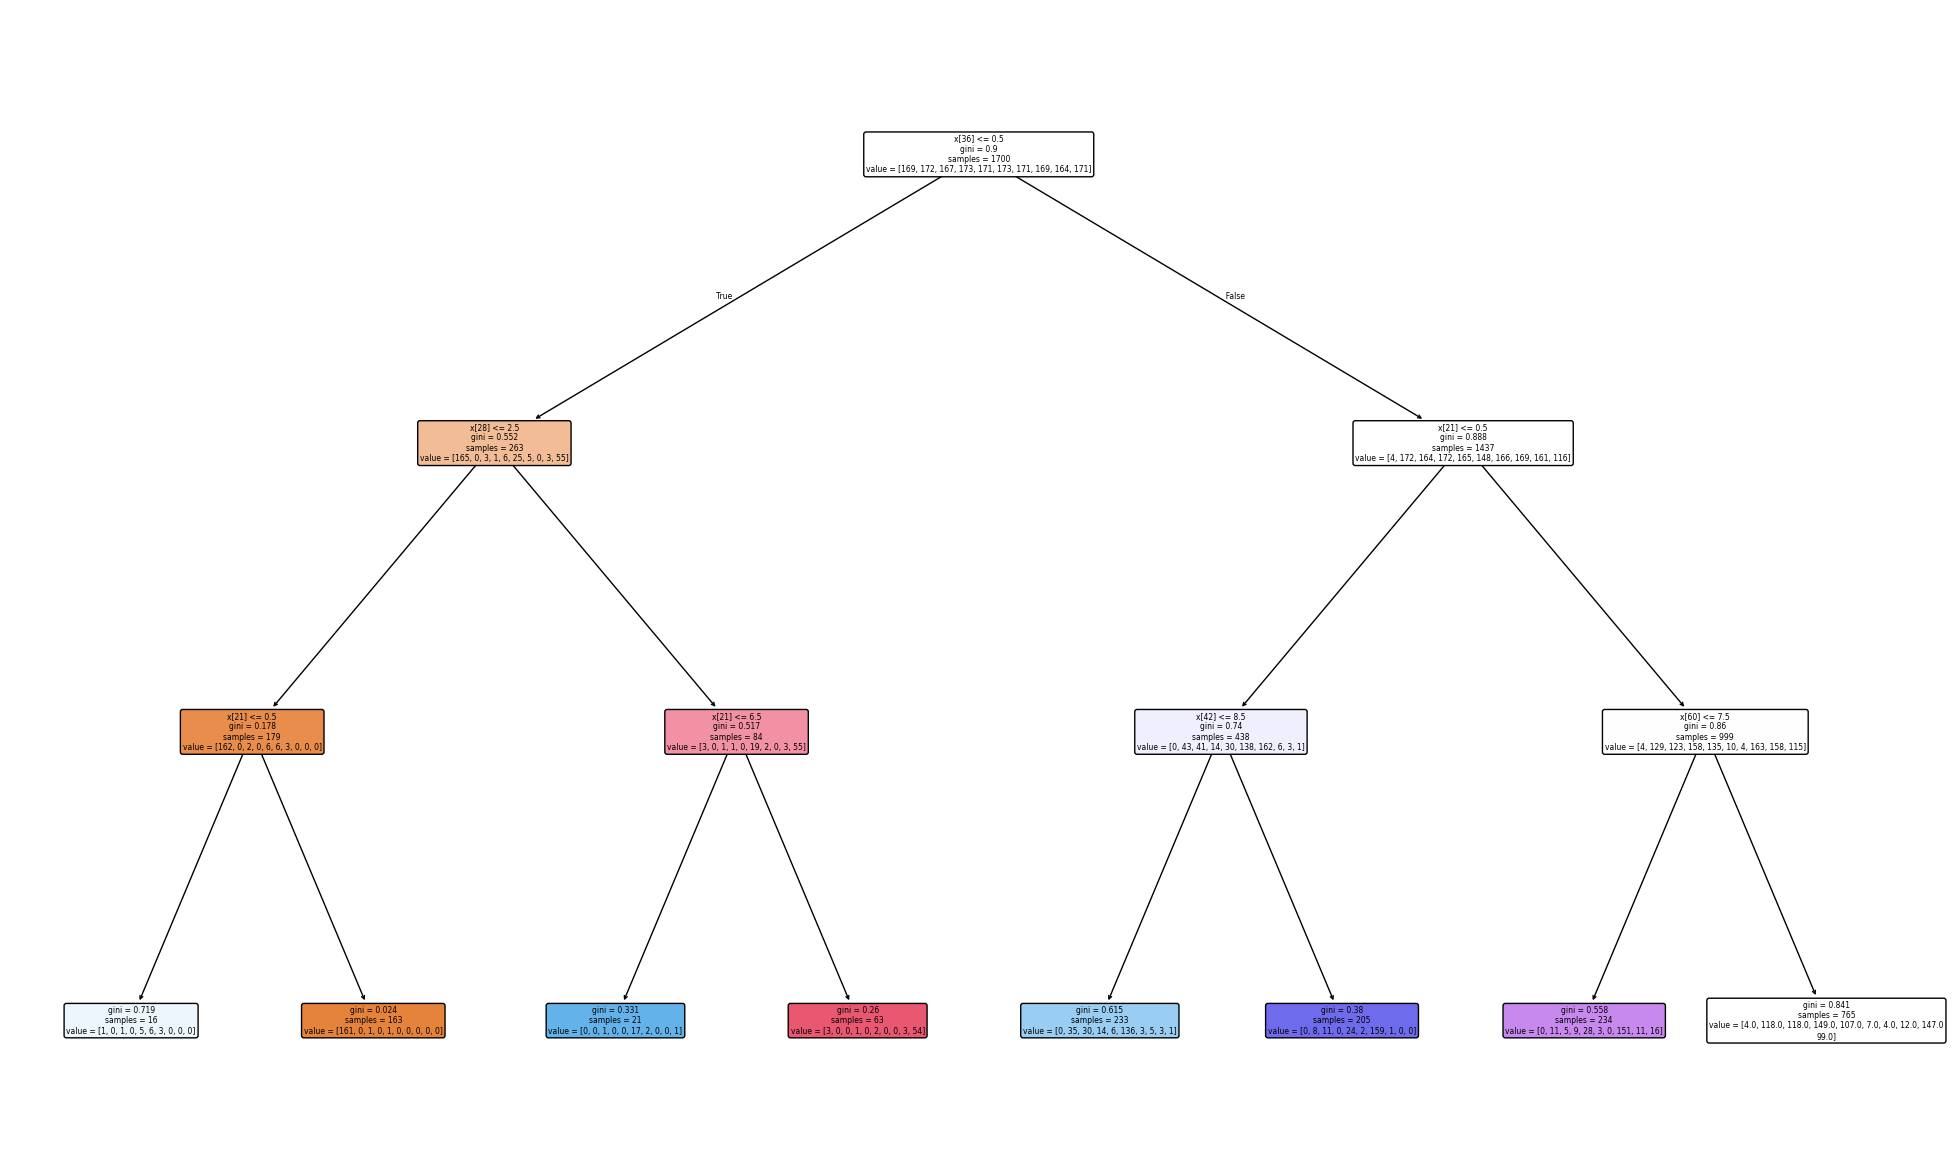

In [70]:

plt.figure(figsize=(25,15))
plot_tree(tree1,filled=True,rounded=True)
plt.show()


##Evaluate

In [71]:
y_predict1 = tree1.predict(X_test)
accuracy_score(y_test,y_predict1)

0.4639175257731959

###tree2

In [74]:
from sklearn.tree import DecisionTreeClassifier
tree2 = DecisionTreeClassifier(random_state=6,max_depth=7)
tree2.fit(X_train,y_train)
y_predict2 = tree2.predict(X_test)
accuracy_score(y_test,y_predict2)

0.7938144329896907

#Qiuz11

In [121]:
from sklearn.tree import DecisionTreeClassifier
tree2 = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=None, # Changed from "None" to None
    random_state=6
)
tree2.fit(X_train,y_train)
y_predict2 = tree2.predict(X_test)
accuracy_score(y_test,y_predict2)

0.8762886597938144